# Phishing Email Detection with Small Open LLMs: a Cross-Corpus, Leakage-Aware, Cost-Aware Benchmark

Group 18, Computer Security, United International University
Jahid Ibna Sinha, Md. Jakaria Alam Saimon, Nowshin Anjum Faria

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Jahid15/phishing-llm-cross-corpus/blob/main/notebooks/phishing_llm_cross_corpus.ipynb)

Source code: https://github.com/Jahid15/phishing-llm-cross-corpus

This notebook walks through the whole experiment. Every table and figure is read
from `results/final/`, which the scripts in `code/final/` produce. By default the
notebook only loads the saved results, so it runs in seconds. Set
`RUN_EXPERIMENTS = True` to run everything again from the raw data.

| Step | Script | What it does |
|---|---|---|
| 1 | `01_prepare_data.py` | download and clean 9 email sources |
| 2 | `02_overlap.py` | find emails shared between corpora (exact and near duplicate) |
| 3 | `03_classical_loco.py` | TF-IDF models, leave-one-corpus-out, raw vs decontaminated |
| 4 | `04_distilbert_loco.py` | fine-tuned DistilBERT, same protocol |
| 5 | `05_llm_eval.py` | six small open LLMs through OpenRouter, measured cost |
| 6 | `06_analysis.py` | final table, confidence intervals, figures |

In [1]:
import os, sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not os.path.exists("phishing-llm-cross-corpus"):
    !git clone -q https://github.com/Jahid15/phishing-llm-cross-corpus
    %cd phishing-llm-cross-corpus
    !pip -q install datasketch
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

RUN_EXPERIMENTS = False   # True = rerun all steps (about 1 to 2 hours, LLM step needs OPENROUTER_API_KEY)

import pandas as pd
from IPython.display import Image, display
pd.set_option("display.width", 200)
R = "results/final/"

## Step 1. Data

Six corpora that contain both phishing/spam and legitimate mail are used for
training and testing. Three more sets are only ever used for testing:
Nazario (real phishing), Nigerian fraud, and E-PhishLLM (emails written by
GPT-4o-mini, English part). Large corpora are capped at 10,000 emails with a
stratified sample (seed 42). Each set also has a fixed evaluation subset of 300
emails (150 for the one-class sets) that every model is scored on.

In [2]:
if RUN_EXPERIMENTS:
    !python code/final/01_prepare_data.py
pd.read_csv(R + "dataset_stats.csv")

,source,role,emails_after_cleaning,emails_used,phishing_or_spam,legitimate,eval_subset
0,spamassassin,train+test,5803,5803,1712,4091,300
1,ceas08,train+test,39091,10000,5574,4426,300
2,trec07,train+test,53638,10000,5460,4540,300
3,ling,train+test,2858,2858,458,2400,300
4,enron,train+test,29604,10000,4689,5311,300
5,kaggle,train+test,17505,10000,3731,6269,300
6,nazario,test only,1554,1554,1554,0,150
7,nigerian,test only,3316,3316,3316,0,150
8,ephishllm,test only,11502,10000,5213,4787,300


## Step 2. How much do the corpora overlap?

Three checks, from strict to loose. `exact_raw` compares the text exactly as a
model reads it. `exact_norm` lowercases and removes all whitespace (our
preliminary method). `near` uses MinHash over 9-character shingles of the
letters and digits only, with Jaccard similarity of at least 0.8.

In [3]:
if RUN_EXPERIMENTS:
    !python code/final/02_overlap.py
pairs = pd.read_csv(R + "overlap_pairs.csv")
view = pairs[pairs.contains == "kaggle"].pivot_table(index="source", columns="level",
        values="emails_of_source_found", fill_value=0)
view["size"] = pairs[pairs.contains == "kaggle"].groupby("source").source_size.first()
print("Emails of each corpus that also appear inside the Kaggle aggregate:")
view

Emails of each corpus that also appear inside the Kaggle aggregate:


level,exact_norm,exact_raw,near,size
source,,,,
enron,187.0,3.0,10229.0,29604
ling,62.0,61.0,2577.0,2858
nigerian,0.0,0.0,69.0,3316
spamassassin,3850.0,2.0,5009.0,5803
trec07,0.0,0.0,2.0,53638


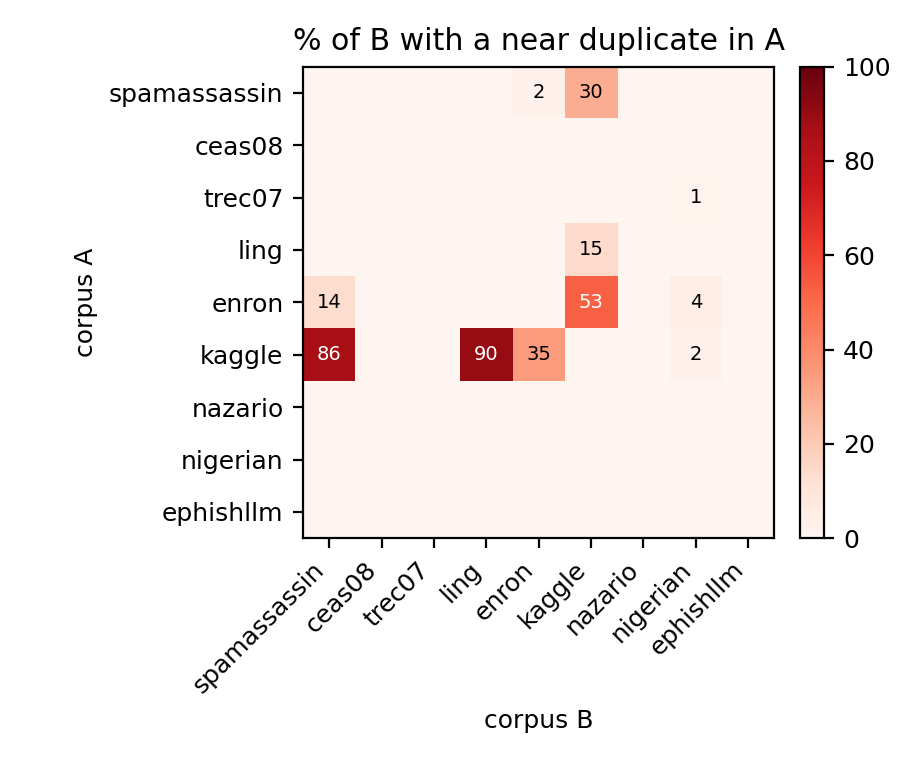

In [4]:
display(Image(R + "figures/overlap_heatmap.png", width=520))

## Step 3. Classical models, leave-one-corpus-out

For each held-out corpus the model is trained on the other five. `loco_raw`
trains on them as they are. `loco_clean` first drops every training email that
has a near duplicate in the test corpus. The difference is score inflation
caused by leaked emails.

In [5]:
if RUN_EXPERIMENTS:
    !python code/final/03_classical_loco.py
inf = pd.read_csv(R + "inflation.csv")
inf[["model", "test", "in_corpus", "loco_raw", "loco_clean", "inflation", "removed"]]

,model,test,in_corpus,loco_raw,loco_clean,inflation,removed
0,TF-IDF + LogReg,ceas08,0.9856,0.8330,0.8321,0.0009,13
1,TF-IDF + LogReg,enron,0.9810,0.9723,0.9187,0.0536,6091
2,TF-IDF + LogReg,ephishllm,NaN,0.6747,0.6747,0.0000,0
3,TF-IDF + LogReg,kaggle,0.9646,0.9759,0.9283,0.0476,11018
4,TF-IDF + LogReg,ling,0.9302,0.9623,0.8473,0.1150,1444
5,TF-IDF + LogReg,nazario,NaN,0.8250,0.8250,0.0000,0
6,TF-IDF + LogReg,nigerian,NaN,0.9964,0.9964,0.0000,79
7,TF-IDF + LogReg,spamassassin,0.9661,0.9474,0.8471,0.1003,3165
8,TF-IDF + LogReg,trec07,0.9854,0.8708,0.8708,0.0000,7
9,TF-IDF + NB,ceas08,0.9841,0.8255,0.8258,-0.0003,13


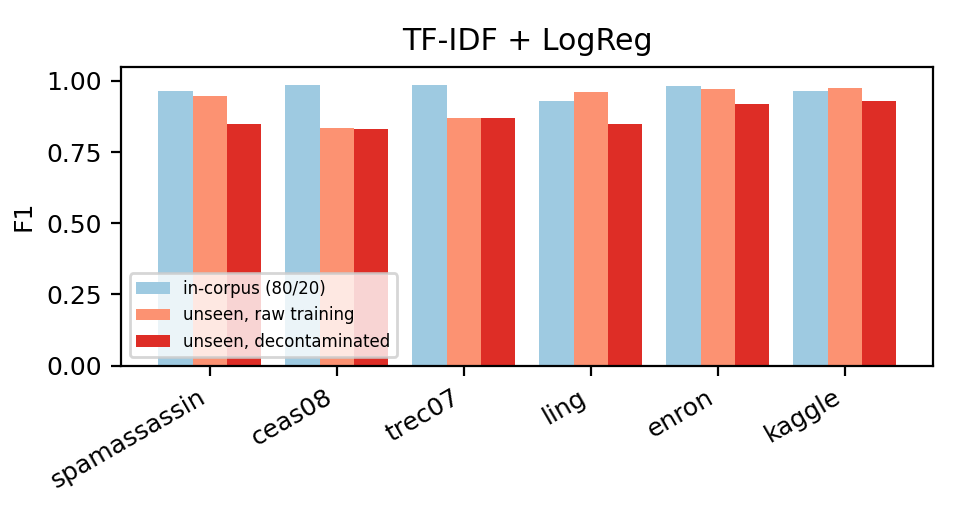

In [6]:
display(Image(R + "figures/incorpus_vs_unseen.png", width=520))

## Step 4. DistilBERT

Fine-tuned locally on the laptop CPU, 1,000 emails per training corpus,
one epoch, 128 tokens. Only the decontaminated setting is run.

In [7]:
if RUN_EXPERIMENTS:
    !python code/final/04_distilbert_loco.py
pd.read_csv(R + "distilbert_timing.csv")

,setting,test,train_size,train_sec,infer_sec_per_1000,device
0,loco_clean,nigerian,6000,539.2,19.17,cpu
1,loco_clean,trec07,5000,448.5,22.24,cpu
2,in_corpus,ling,2000,180.5,21.98,cpu
3,loco_clean,nazario,6000,539.2,19.00,cpu
4,in_corpus,trec07,2000,158.8,20.81,cpu
5,loco_clean,enron,5000,477.0,21.09,cpu
6,loco_clean,ephishllm,6000,539.2,18.69,cpu
7,loco_clean,kaggle,4075,330.7,19.33,cpu
8,in_corpus,ceas08,2000,157.0,18.88,cpu
9,in_corpus,kaggle,2000,163.8,19.57,cpu


## Step 5. Small open LLMs

Zero-shot for six models and few-shot (four examples from the other corpora)
for two. Temperature 0, five output tokens, emails cut to 1,500 characters. The
cost is what OpenRouter charged for each call.

In [8]:
if RUN_EXPERIMENTS:
    !python code/final/05_llm_eval.py --mode zero --models all
pd.read_csv(R + "llm_cost.csv")

,model,usd_per_1000,total_usd,calls,unparsed_pct,median_latency_s,tokens_in_mean
0,Qwen-2.5-7B,0.03073,0.07375,2400,0.00000,0.6135,301.28000
1,Llama-3.1-8B,0.01114,0.02674,2400,0.79167,0.7450,299.44458
2,Phi-4-14B,0.02078,0.04987,2400,37.08333,0.6020,288.03958
3,Qwen-2.5-7B few-shot,0.07372,0.17693,2400,0.00000,0.6460,731.28000
4,Llama-3.2-3B,0.01632,0.03917,2400,0.08333,0.5280,303.30958
5,Llama-3.2-1B,0.00868,0.02083,2400,1.00000,0.5270,292.72750
6,Gemma-3-12B,0.01578,0.03786,2400,0.04167,0.9380,306.60250
7,Llama-3.2-3B few-shot,0.03715,0.08916,2400,0.00000,0.5330,715.36542


## Step 6. The final table

`unseen_f1_mean` is the mean F1 over the six held-out corpora, with a 95%
bootstrap interval. `unseen_f1_worst` is the lowest of the six.
`ai_phishing_f1` is on E-PhishLLM. The two recall columns are detection rates
on real phishing (Nazario) and fraud (Nigerian). Cost is USD per 1,000 emails
(zero for local models).

In [9]:
if RUN_EXPERIMENTS:
    !python code/final/06_analysis.py
pd.read_csv(R + "main_table.csv")

,model,type,in_corpus_f1,unseen_f1_mean,unseen_f1_ci,unseen_f1_worst,false_alarm_rate,false_alarm_worst,ai_phishing_f1,nazario_recall,nigerian_recall,usd_per_1000,unparsed_pct
0,Qwen-2.5-7B few-shot,LLM,NaN,0.937,0.925-0.948,0.844,0.048,0.113,0.598,0.847,1.000,0.0737,0.0
1,Qwen-2.5-7B,LLM,NaN,0.928,0.915-0.940,0.850,0.030,0.080,0.819,0.940,1.000,0.0307,0.0
2,TF-IDF + LogReg,classical,0.969,0.901,0.886-0.916,0.807,0.093,0.173,0.640,0.713,1.000,0.0000,0.0
3,Llama-3.2-3B few-shot,LLM,NaN,0.901,0.885-0.915,0.848,0.027,0.080,0.438,0.680,0.993,0.0371,0.0
4,TF-IDF + NB,classical,0.929,0.895,0.879-0.909,0.773,0.066,0.113,0.631,0.600,0.987,0.0000,0.0
5,DistilBERT,fine-tuned encoder,0.975,0.891,0.875-0.906,0.838,0.063,0.100,0.493,0.760,0.947,0.0000,0.0
6,Gemma-3-12B,LLM,NaN,0.882,0.866-0.896,0.768,0.251,0.573,0.955,0.980,1.000,0.0158,0.0
7,Llama-3.1-8B,LLM,NaN,0.881,0.865-0.896,0.779,0.214,0.493,0.817,0.973,1.000,0.0111,0.8
8,Llama-3.2-3B,LLM,NaN,0.850,0.832-0.868,0.799,0.051,0.113,0.507,0.827,1.000,0.0163,0.1
9,Phi-4-14B,LLM,NaN,0.727,0.702-0.749,0.621,0.276,0.340,0.759,0.660,0.513,0.0208,37.1


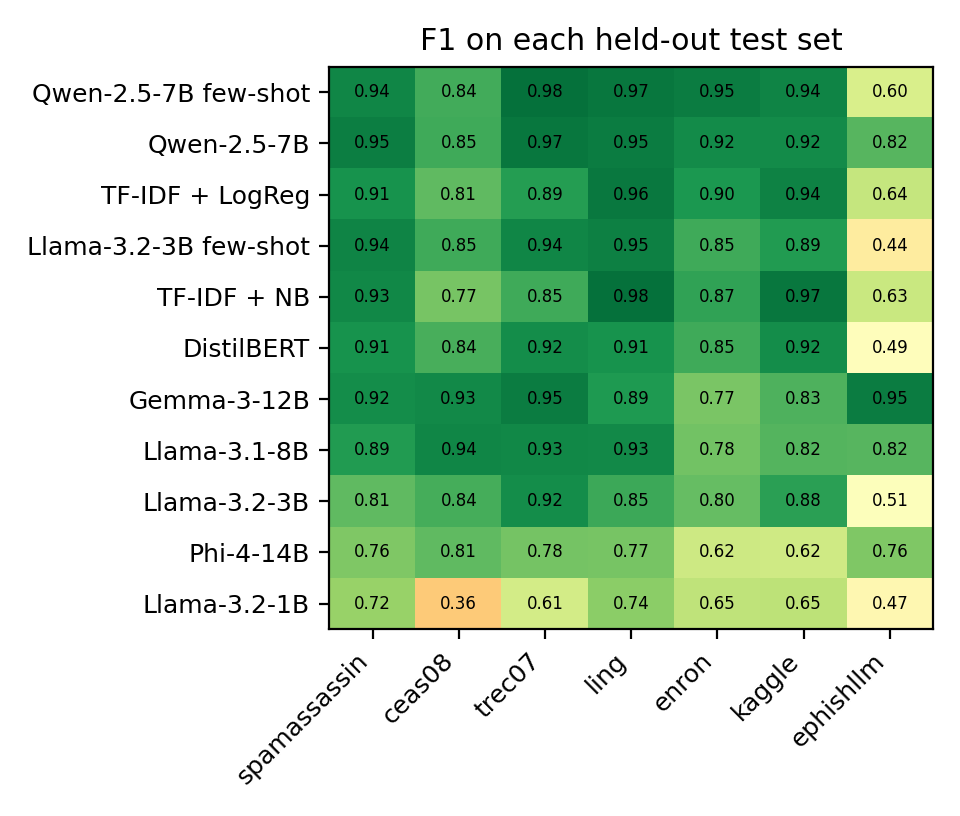

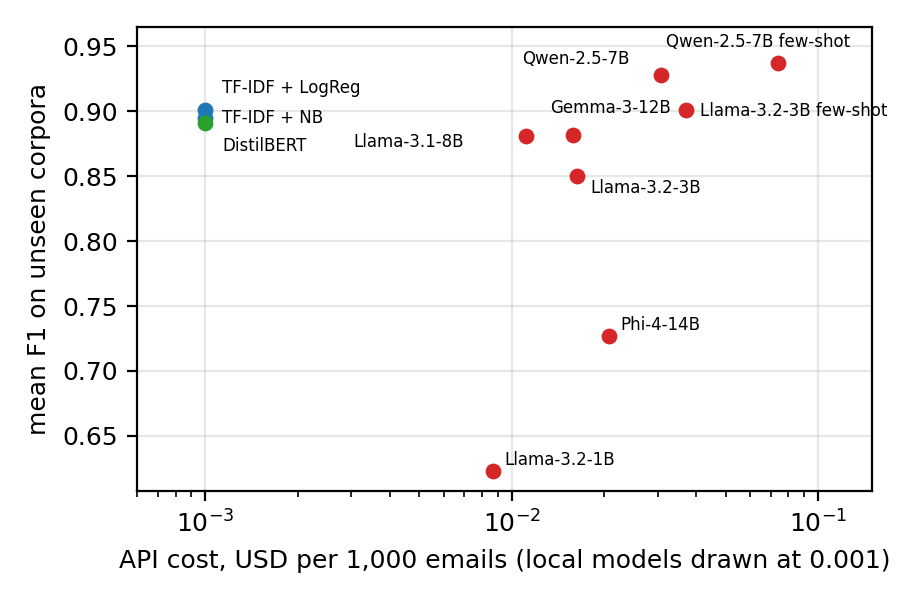

In [10]:
display(Image(R + "figures/per_corpus_f1.png", width=560))
display(Image(R + "figures/f1_vs_cost.png", width=560))

## What to take away

See `paper/paper.pdf` for the discussion and `RESEARCH_LOG.md` for the full
story of how the project developed.